# 🫁 ClearLung — Pneumonia Detection from Chest X-Rays
**Course:** ITAI 1378 – Computer Vision and AI  
**Model:** ResNet-18 (Transfer Learning, PyTorch)  
**Dataset:** Kaggle Chest X-Ray Images (Pneumonia)

---
### Notebook Sections
1. Environment Setup & Kaggle Download  
2. Exploratory Data Analysis (EDA)  
3. Data Loading & Preprocessing  
4. Model Definition (ResNet-18 Fine-Tuning)  
5. Training Loop  
6. Evaluation (Accuracy, Recall, Confusion Matrix)  
7. Single-Image Inference Demo  


## 1. Environment Setup & Kaggle Download

In [ ]:
# Install / confirm dependencies
# Run this cell once in Colab; everything else is pre-installed
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("kaggle", "matplotlib", "seaborn", "scikit-learn", "Pillow")
print("✅ Dependencies ready")

In [ ]:
# ── Kaggle credentials ────────────────────────────────────────────────────
# Option A (Colab): Upload your kaggle.json when prompted
# Option B: Set env vars directly (replace with your values)
#
# import os
# os.environ["KAGGLE_USERNAME"] = "your_username"
# os.environ["KAGGLE_KEY"]      = "your_api_key"

import os

# Option A — upload kaggle.json interactively (Colab only)
try:
    from google.colab import files
    print("Upload your kaggle.json from https://www.kaggle.com/settings")
    uploaded = files.upload()
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    kaggle_json = os.path.expanduser("~/.kaggle/kaggle.json")
    with open(kaggle_json, "wb") as f:
        f.write(list(uploaded.values())[0])
    os.chmod(kaggle_json, 0o600)
    print("✅ kaggle.json saved")
except ImportError:
    print("Not in Colab — make sure KAGGLE_USERNAME / KAGGLE_KEY env vars are set")

In [3]:
# ── Download & unzip dataset ──────────────────────────────────────────────
import subprocess, pathlib

DATASET = "paultimothymooney/chest-xray-pneumonia"
DATA_DIR = pathlib.Path("chest_xray")

if not DATA_DIR.exists():
    subprocess.run(["kaggle", "datasets", "download", "-d", DATASET], check=True)
    subprocess.run(["unzip", "-q", "chest-xray-pneumonia.zip"], check=True)
    print("✅ Dataset downloaded and unzipped")
else:
    print("✅ Dataset already present — skipping download")

# Confirm structure
for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        p = DATA_DIR / split / cls
        count = len(list(p.glob("*.jpeg"))) + len(list(p.glob("*.jpg")))
        print(f"  {split:5s} / {cls:9s} → {count:5d} images")

✅ Dataset downloaded and unzipped
  train / NORMAL    →  1341 images
  train / PNEUMONIA →  3875 images
  val   / NORMAL    →     8 images
  val   / PNEUMONIA →     8 images
  test  / NORMAL    →   234 images
  test  / PNEUMONIA →   390 images


## 2. Exploratory Data Analysis (EDA)

/tmp/ipykernel_626/3540981369.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


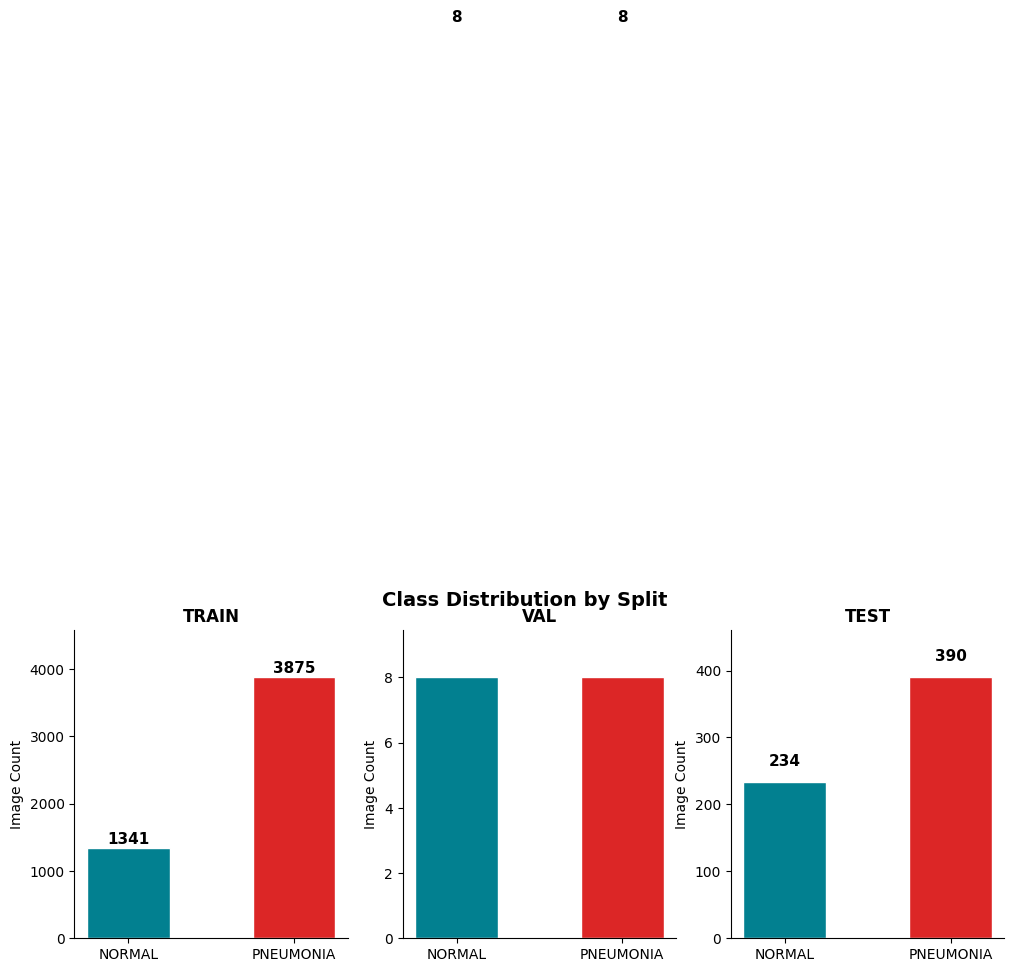

⚠️  Note: Training set is imbalanced — ~4× more PNEUMONIA than NORMAL. We'll handle this with a weighted loss.


In [4]:
import pathlib, random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

DATA_DIR = pathlib.Path("chest_xray")

# ── Class distribution bar chart ──────────────────────────────────────────
splits   = ["train", "val", "test"]
classes  = ["NORMAL", "PNEUMONIA"]
colors   = {"NORMAL": "#028090", "PNEUMONIA": "#DC2626"}

counts = {s: {} for s in splits}
for split in splits:
    for cls in classes:
        p = DATA_DIR / split / cls
        counts[split][cls] = len(list(p.glob("*.jpeg")) + list(p.glob("*.jpg")))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Class Distribution by Split", fontsize=14, fontweight="bold")

for ax, split in zip(axes, splits):
    vals = [counts[split][c] for c in classes]
    bars = ax.bar(classes, vals, color=[colors[c] for c in classes], edgecolor="white", width=0.5)
    ax.set_title(split.upper(), fontweight="bold")
    ax.set_ylabel("Image Count")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(v), ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.18)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("⚠️  Note: Training set is imbalanced — ~4× more PNEUMONIA than NORMAL. We'll handle this with a weighted loss.")

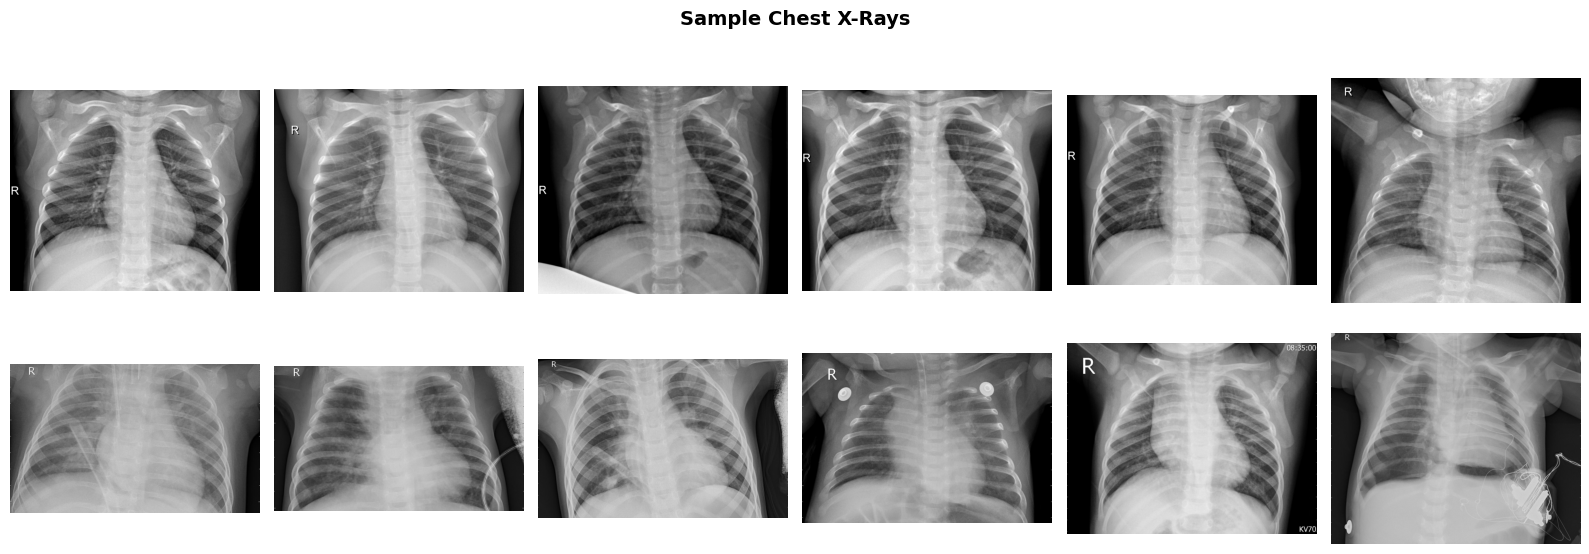

In [5]:
# ── Sample images grid ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Sample Chest X-Rays", fontsize=14, fontweight="bold")

for row, cls in enumerate(classes):
    imgs = list((DATA_DIR / "train" / cls).glob("*.jpeg"))[:6]
    for col, img_path in enumerate(imgs):
        ax = axes[row][col]
        img = mpimg.imread(img_path)
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls, fontsize=11, fontweight="bold",
                          color=colors[cls], rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig("eda_sample_images.png", dpi=120, bbox_inches="tight")
plt.show()

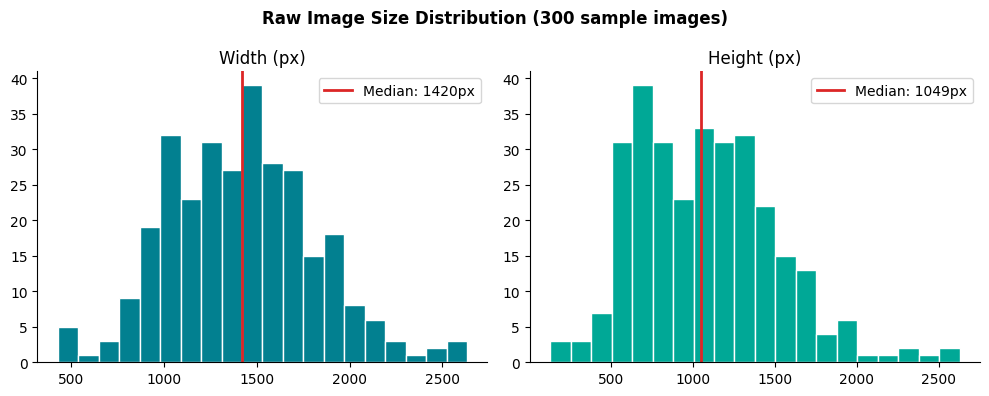

Width  — min: 428, max: 2633, median: 1420
Height — min: 132, max: 2628, median: 1049
→ All images will be resized to 224×224 for ResNet-18 input.


In [6]:
# ── Image size distribution ───────────────────────────────────────────────
from PIL import Image
import numpy as np

widths, heights = [], []
sample_paths = list((DATA_DIR / "train" / "NORMAL").glob("*.jpeg"))[:150] + \
               list((DATA_DIR / "train" / "PNEUMONIA").glob("*.jpeg"))[:150]

for p in sample_paths:
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Raw Image Size Distribution (300 sample images)", fontsize=12, fontweight="bold")

axes[0].hist(widths, bins=20, color="#028090", edgecolor="white")
axes[0].set_title("Width (px)")
axes[0].axvline(np.median(widths), color="#DC2626", lw=2, label=f"Median: {int(np.median(widths))}px")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(heights, bins=20, color="#00A896", edgecolor="white")
axes[1].set_title("Height (px)")
axes[1].axvline(np.median(heights), color="#DC2626", lw=2, label=f"Median: {int(np.median(heights))}px")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
print(f"Width  — min: {min(widths)}, max: {max(widths)}, median: {int(np.median(widths))}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, median: {int(np.median(heights))}")
print("→ All images will be resized to 224×224 for ResNet-18 input.")

## 3. Data Loading & Preprocessing

In [7]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# ── Hyperparameters ───────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 2  # set to 0 if you hit multiprocessing errors in Colab

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
  GPU: Tesla T4


In [8]:
# ── Transforms ───────────────────────────────────────────────────────────
# ImageNet mean/std (ResNet-18 was pre-trained on ImageNet)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # X-rays are grayscale; ResNet expects 3ch
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ── Datasets ─────────────────────────────────────────────────────────────
train_dataset = ImageFolder(DATA_DIR / "train", transform=train_transform)
val_dataset   = ImageFolder(DATA_DIR / "val",   transform=val_test_transform)
test_dataset  = ImageFolder(DATA_DIR / "test",  transform=val_test_transform)

CLASS_NAMES = train_dataset.classes   # ['NORMAL', 'PNEUMONIA']
print(f"Classes: {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['NORMAL', 'PNEUMONIA']
Train: 5216 | Val: 16 | Test: 624


In [9]:
# ── Weighted sampler to handle class imbalance ───────────────────────────
targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

# ── DataLoaders ───────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=NUM_WORKERS)

print(f"Class counts (train): NORMAL={class_counts[0]}, PNEUMONIA={class_counts[1]}")
print(f"Sample weights:       NORMAL={class_weights[0]:.4f}, PNEUMONIA={class_weights[1]:.4f}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Class counts (train): NORMAL=1341, PNEUMONIA=3875
Sample weights:       NORMAL=0.0007, PNEUMONIA=0.0003
Train batches: 163 | Val batches: 1 | Test batches: 20


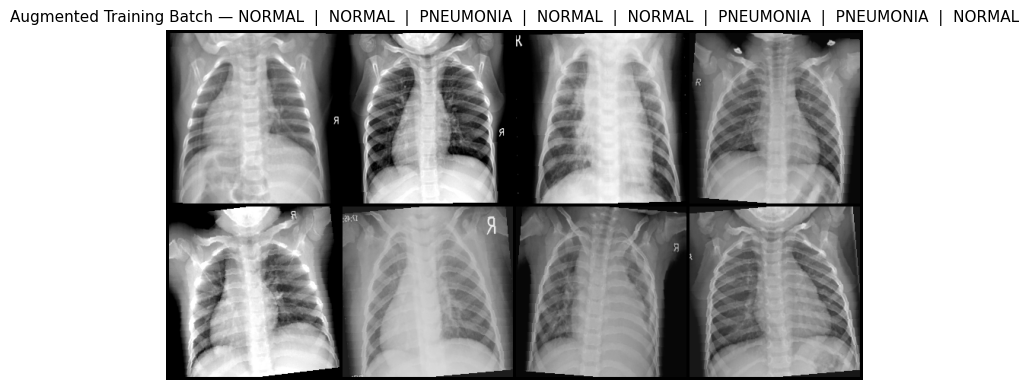

In [10]:
# ── Sanity check: visualise one augmented batch ───────────────────────────
import torchvision

images, labels = next(iter(train_loader))

def denormalize(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std  = torch.tensor(STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

grid = torchvision.utils.make_grid(denormalize(images[:8]), nrow=4, padding=4)
plt.figure(figsize=(12, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Augmented Training Batch — " + "  |  ".join([CLASS_NAMES[l] for l in labels[:8].tolist()]), fontsize=11)
plt.tight_layout()
plt.savefig("eda_augmented_batch.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Model Definition — ResNet-18 Fine-Tuning

In [11]:
import torch.nn as nn
import torchvision.models as models

def build_model(num_classes=2, freeze_backbone=True):
    """
    Load ImageNet-pretrained ResNet-18 and replace the final
    fully-connected layer for binary classification.

    Args:
        num_classes    : number of output classes (2: Normal / Pneumonia)
        freeze_backbone: if True, freeze all layers except the FC head
    Returns:
        model ready for training
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the classification head
    in_features = model.fc.in_features  # 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes),
    )

    return model

model = build_model(num_classes=2, freeze_backbone=True)
model = model.to(DEVICE)

# Count trainable vs frozen parameters
total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}  ({100*trainable/total:.1f}%)")
print(f"Frozen parameters:    {total-trainable:,}  ({100*(total-trainable)/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 103MB/s]


Total parameters:     11,177,538
Trainable parameters: 1,026  (0.0%)
Frozen parameters:    11,176,512  (100.0%)


## 5. Training Loop

In [13]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time, copy

# ── Loss, Optimizer, Scheduler ────────────────────────────────────────────
# Weighted loss as an additional guard against class imbalance
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

NUM_EPOCHS = 10  # increase to 20+ for better accuracy

print(f"Criterion : CrossEntropyLoss (weighted)")
print(f"Optimizer : Adam  lr=1e-3, weight_decay=1e-4")
print(f"Scheduler : ReduceLROnPlateau (patience=2, factor=0.5)")
print(f"Epochs    : {NUM_EPOCHS}")

Criterion : CrossEntropyLoss (weighted)
Optimizer : Adam  lr=1e-3, weight_decay=1e-4
Scheduler : ReduceLROnPlateau (patience=2, factor=0.5)
Epochs    : 10


In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

print("Helper functions defined — ready to train.")

Helper functions defined — ready to train.


In [15]:
# ── Main training loop ────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  "
          f"({elapsed:.0f}s)")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, "clearlung_best.pth")
        print(f"  ✅ Best model saved (val_loss={best_val_loss:.4f})")

# Restore best weights
model.load_state_dict(best_model_wts)
print("\n🏁 Training complete. Best weights loaded.")

Epoch [01/10]  Train Loss: 0.3720  Acc: 0.7546  |  Val Loss: 0.3163  Acc: 0.6875  (111s)
  ✅ Best model saved (val_loss=0.3163)
Epoch [02/10]  Train Loss: 0.2469  Acc: 0.8602  |  Val Loss: 0.1916  Acc: 0.9375  (104s)
  ✅ Best model saved (val_loss=0.1916)
Epoch [03/10]  Train Loss: 0.2335  Acc: 0.8656  |  Val Loss: 0.1834  Acc: 0.9375  (105s)
  ✅ Best model saved (val_loss=0.1834)
Epoch [04/10]  Train Loss: 0.2142  Acc: 0.8817  |  Val Loss: 0.1850  Acc: 0.8750  (104s)
Epoch [05/10]  Train Loss: 0.2100  Acc: 0.8832  |  Val Loss: 0.1982  Acc: 0.8125  (105s)
Epoch [06/10]  Train Loss: 0.2144  Acc: 0.8850  |  Val Loss: 0.1527  Acc: 0.9375  (103s)
  ✅ Best model saved (val_loss=0.1527)
Epoch [07/10]  Train Loss: 0.2119  Acc: 0.8852  |  Val Loss: 0.1520  Acc: 0.9375  (104s)
  ✅ Best model saved (val_loss=0.1520)
Epoch [08/10]  Train Loss: 0.2166  Acc: 0.8752  |  Val Loss: 0.1370  Acc: 0.9375  (102s)
  ✅ Best model saved (val_loss=0.1370)
Epoch [09/10]  Train Loss: 0.2074  Acc: 0.8926  |  Val

In [17]:
# ── Phase 2: Unfreeze & fine-tune entire network (optional) ──────────────
# After the FC head has converged, unfreeze the backbone and train
# at a much smaller learning rate for a few more epochs.

UNFREEZE_EPOCHS = 5
UNFREEZE_LR     = 1e-5

for param in model.parameters():
    param.requires_grad = True

optimizer2  = optim.Adam(model.parameters(), lr=UNFREEZE_LR, weight_decay=1e-4)
scheduler2  = ReduceLROnPlateau(optimizer2, mode="min", factor=0.5, patience=2)

print(f"Unfreezing all layers — fine-tuning for {UNFREEZE_EPOCHS} epochs at lr={UNFREEZE_LR}")

for epoch in range(1, UNFREEZE_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer2, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler2.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    print(f"FT Epoch [{epoch:02d}/{UNFREEZE_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  ({elapsed:.0f}s)")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, "clearlung_best.pth")
        print(f"  ✅ Best model saved (val_loss={best_val_loss:.4f})")

model.load_state_dict(best_model_wts)
print("\n✅ Full fine-tuning complete.")

Unfreezing all layers — fine-tuning for 5 epochs at lr=1e-05
FT Epoch [01/5]  Train Loss: 0.1364  Acc: 0.9354  |  Val Loss: 0.0685  Acc: 0.9375  (111s)
  ✅ Best model saved (val_loss=0.0685)
FT Epoch [02/5]  Train Loss: 0.0960  Acc: 0.9517  |  Val Loss: 0.0817  Acc: 1.0000  (107s)
FT Epoch [03/5]  Train Loss: 0.0776  Acc: 0.9601  |  Val Loss: 0.1070  Acc: 1.0000  (107s)
FT Epoch [04/5]  Train Loss: 0.0663  Acc: 0.9693  |  Val Loss: 0.0362  Acc: 1.0000  (105s)
  ✅ Best model saved (val_loss=0.0362)
FT Epoch [05/5]  Train Loss: 0.0569  Acc: 0.9741  |  Val Loss: 0.0359  Acc: 1.0000  (107s)
  ✅ Best model saved (val_loss=0.0359)

✅ Full fine-tuning complete.


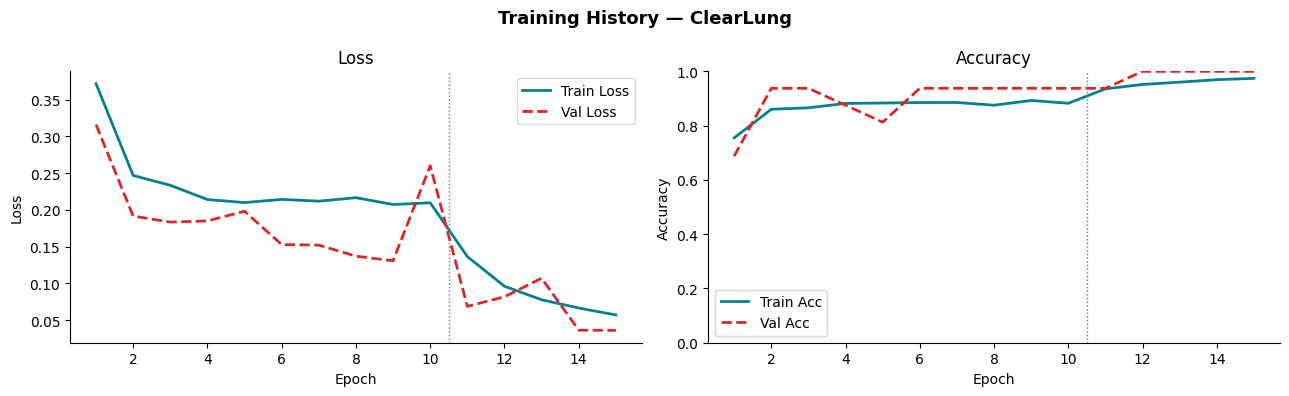

In [18]:
# ── Training curves ───────────────────────────────────────────────────────
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Training History — ClearLung", fontsize=13, fontweight="bold")

axes[0].plot(epochs, history["train_loss"], color="#028090", label="Train Loss", lw=2)
axes[0].plot(epochs, history["val_loss"],   color="#DC2626", label="Val Loss",   lw=2, linestyle="--")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].spines[["top","right"]].set_visible(False)
if NUM_EPOCHS > 0:
    axes[0].axvline(NUM_EPOCHS + 0.5, color="#64748B", lw=1, linestyle=":", label="Unfreeze →")

axes[1].plot(epochs, history["train_acc"], color="#028090", label="Train Acc", lw=2)
axes[1].plot(epochs, history["val_acc"],   color="#DC2626", label="Val Acc",   lw=2, linestyle="--")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].spines[["top","right"]].set_visible(False)
if NUM_EPOCHS > 0:
    axes[1].axvline(NUM_EPOCHS + 0.5, color="#64748B", lw=1, linestyle=":", label="Unfreeze →")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Evaluation — Test Set

In [19]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score,
    roc_curve, auc,
)
import seaborn as sns

# ── Run on test set ───────────────────────────────────────────────────────
test_loss, test_acc, all_preds, all_labels = evaluate(model, test_loader, criterion, DEVICE)

accuracy  = accuracy_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds, pos_label=1)      # pneumonia = class 1
precision = precision_score(all_labels, all_preds, pos_label=1)
f1        = f1_score(all_labels, all_preds, pos_label=1)

print("=" * 50)
print("  TEST SET RESULTS")
print("=" * 50)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.1f}%)  ← PRIMARY METRIC")
print(f"  Precision : {precision:.4f}  ({precision*100:.1f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.1f}%)")
print(f"  Loss      : {test_loss:.4f}")
print("=" * 50)
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

  TEST SET RESULTS
  Accuracy  : 0.9151  (91.5%)
  Recall    : 0.9795  (97.9%)  ← PRIMARY METRIC
  Precision : 0.8946  (89.5%)
  F1-Score  : 0.9351  (93.5%)
  Loss      : 0.3719

              precision    recall  f1-score   support

      NORMAL       0.96      0.81      0.88       234
   PNEUMONIA       0.89      0.98      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.89      0.91       624
weighted avg       0.92      0.92      0.91       624



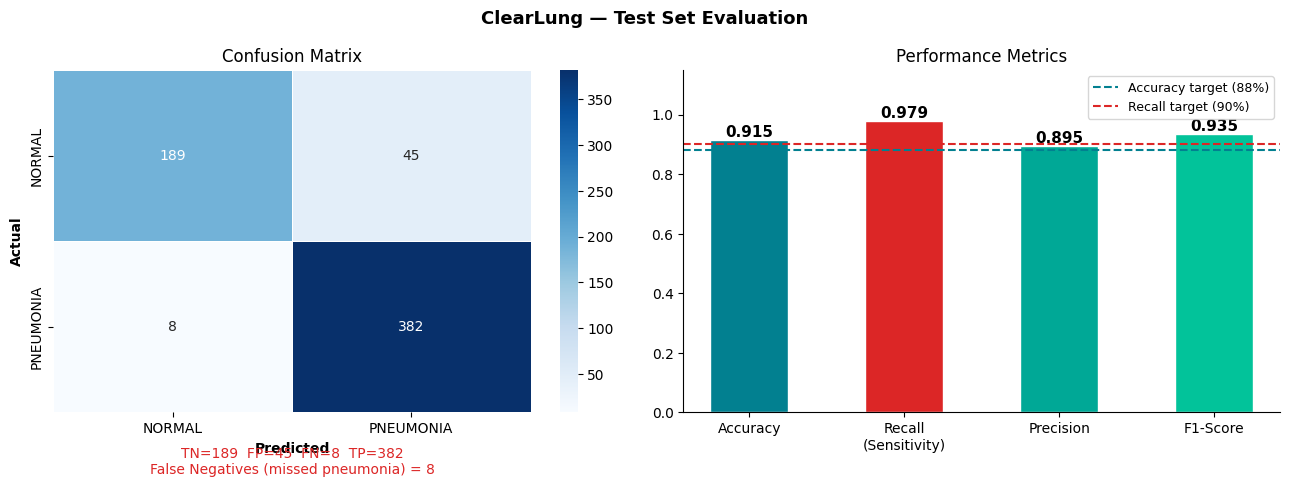

✅ Recall target MET (≥ 90%)
✅ Accuracy target MET (≥ 88%)


In [21]:
# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ClearLung — Test Set Evaluation", fontsize=13, fontweight="bold")

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_xlabel("Predicted", fontweight="bold")
axes[0].set_ylabel("Actual",    fontweight="bold")
axes[0].set_title("Confusion Matrix")

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.18,
    f"""TN={tn}  FP={fp}  FN={fn}  TP={tp}
False Negatives (missed pneumonia) = {fn}""",
    ha="center", transform=axes[0].transAxes, fontsize=10, color="#DC2626")

# Metrics bar chart
metric_names = ["Accuracy", "Recall\n(Sensitivity)", "Precision", "F1-Score"]
metric_vals  = [accuracy, recall, precision, f1]
bar_colors   = ["#028090", "#DC2626", "#00A896", "#02C39A"]
bars = axes[1].bar(metric_names, metric_vals, color=bar_colors, edgecolor="white", width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_title("Performance Metrics")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].axhline(0.88, color="#028090", lw=1.5, linestyle="--", label="Accuracy target (88%)")
axes[1].axhline(0.90, color="#DC2626", lw=1.5, linestyle="--", label="Recall target (90%)")
axes[1].legend(fontsize=9)
for bar, v in zip(bars, metric_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=120, bbox_inches="tight")
plt.show()

if recall >= 0.90:
    print("✅ Recall target MET (≥ 90%)")
else:
    print(f"⚠️  Recall target NOT yet met ({recall*100:.1f}% < 90%). Consider more epochs or EfficientNet-B0.")
if accuracy >= 0.88:
    print("✅ Accuracy target MET (≥ 88%)")
else:
    print(f"⚠️  Accuracy target NOT yet met ({accuracy*100:.1f}% < 88%). Consider more epochs.")

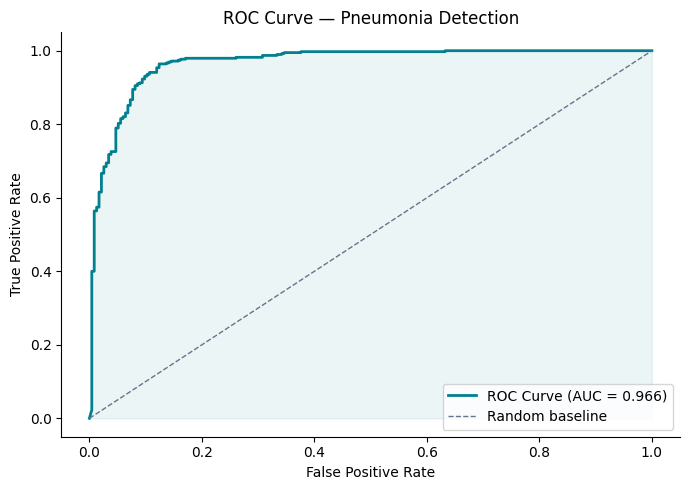

AUC: 0.9662


In [22]:
# ── ROC Curve ─────────────────────────────────────────────────────────────
# Collect softmax probabilities for class 1 (Pneumonia)
model.eval()
probs_pneumonia = []
y_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = torch.softmax(model(images), dim=1)
        probs_pneumonia.extend(outputs[:, 1].cpu().numpy())
        y_true.extend(labels.numpy())

fpr, tpr, _ = roc_curve(y_true, probs_pneumonia)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#028090", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="#64748B", lw=1, linestyle="--", label="Random baseline")
plt.fill_between(fpr, tpr, alpha=0.08, color="#028090")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Pneumonia Detection")
plt.legend(loc="lower right")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"AUC: {roc_auc:.4f}")

## 7. Single-Image Inference Demo

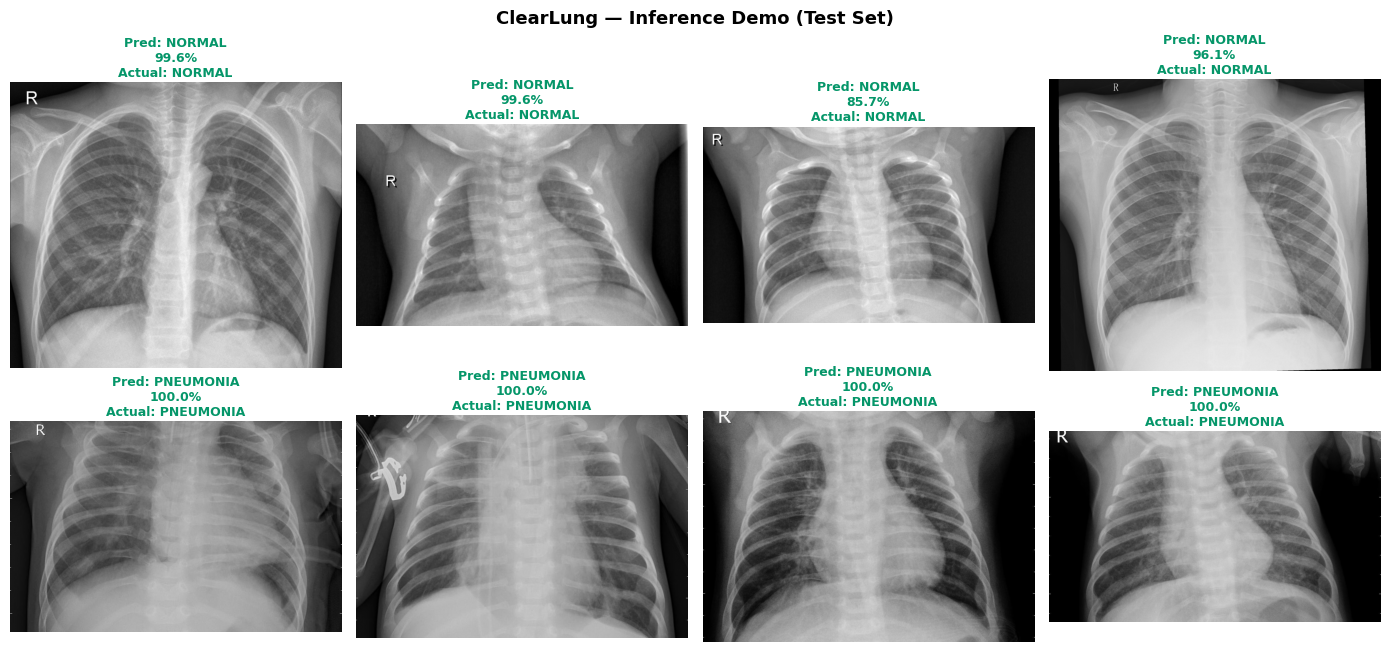

In [23]:
import torch.nn.functional as F

def predict_image(image_path, model, transform, class_names, device):
    """
    Run inference on a single chest X-ray image.

    Args:
        image_path  : path to a JPEG/PNG chest X-ray
        model       : trained PyTorch model
        transform   : val/test transform pipeline
        class_names : list of class labels
        device      : torch device
    Returns:
        predicted_class, confidence, all_probs
    """
    from PIL import Image
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).squeeze().cpu()

    pred_idx  = probs.argmax().item()
    confidence = probs[pred_idx].item()
    return class_names[pred_idx], confidence, probs.numpy()


def demo_grid(data_dir, model, transform, class_names, device, n=4):
    """Show n Normal + n Pneumonia test images with predictions."""
    import random, pathlib
    from matplotlib.patches import FancyBboxPatch

    samples = []
    for cls in class_names:
        imgs = list((pathlib.Path(data_dir) / "test" / cls).glob("*.jpeg"))
        samples += random.sample(imgs, min(n, len(imgs)))

    fig, axes = plt.subplots(2, n, figsize=(n * 3.5, 7))
    fig.suptitle("ClearLung — Inference Demo (Test Set)", fontsize=13, fontweight="bold")

    for ax, img_path in zip(axes.flat, samples):
        pred, conf, probs = predict_image(img_path, model, transform, class_names, device)
        actual = img_path.parent.name
        img_display = plt.imread(img_path)
        ax.imshow(img_display, cmap="gray")
        ax.axis("off")

        correct = pred == actual
        color   = "#059669" if correct else "#DC2626"
        label   = f"Pred: {pred}\n{conf*100:.1f}%\nActual: {actual}"
        ax.set_title(label, fontsize=9, color=color, fontweight="bold", pad=4)

    plt.tight_layout()
    plt.savefig("inference_demo.png", dpi=120, bbox_inches="tight")
    plt.show()

demo_grid(DATA_DIR, model, val_test_transform, CLASS_NAMES, DEVICE, n=4)

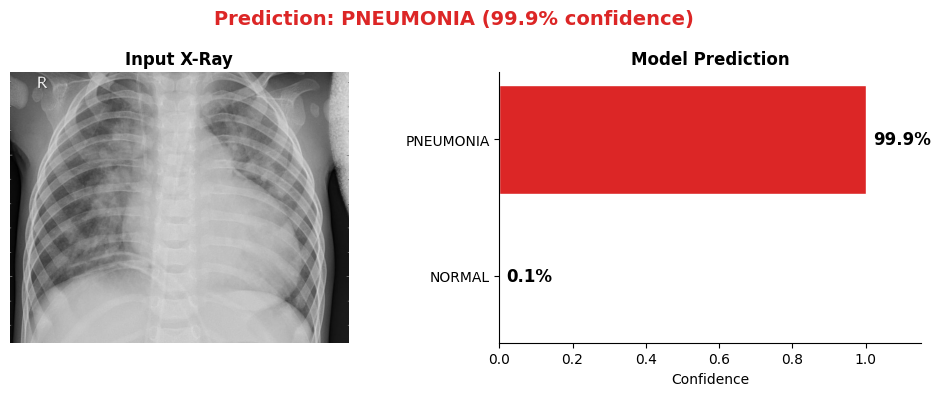


File: chest_xray/test/PNEUMONIA/person143_bacteria_688.jpeg
Prediction : PNEUMONIA
Confidence : 99.9%
NORMAL     : 0.1%
PNEUMONIA  : 99.9%


In [24]:
# ── Predict a single custom image ─────────────────────────────────────────
# Change this path to any chest X-ray you want to test
TEST_IMAGE = str(list((DATA_DIR / "test" / "PNEUMONIA").glob("*.jpeg"))[0])

pred_class, confidence, probs = predict_image(
    TEST_IMAGE, model, val_test_transform, CLASS_NAMES, DEVICE
)

# Display
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(plt.imread(TEST_IMAGE), cmap="gray")
axes[0].axis("off")
axes[0].set_title("Input X-Ray", fontweight="bold")

bar_colors = ["#028090" if c == "NORMAL" else "#DC2626" for c in CLASS_NAMES]
bars = axes[1].barh(CLASS_NAMES, probs, color=bar_colors, edgecolor="white")
axes[1].set_xlim(0, 1.15)
axes[1].set_xlabel("Confidence")
axes[1].set_title("Model Prediction", fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)
for bar, v in zip(bars, probs):
    axes[1].text(v + 0.02, bar.get_y() + bar.get_height()/2,
                 f"{v*100:.1f}%", va="center", fontsize=12, fontweight="bold")

result_color = "#DC2626" if pred_class == "PNEUMONIA" else "#059669"
fig.suptitle(f"Prediction: {pred_class} ({confidence*100:.1f}% confidence)",
             fontsize=14, fontweight="bold", color=result_color)
plt.tight_layout()
plt.savefig("single_inference.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nFile: {TEST_IMAGE}")
print(f"Prediction : {pred_class}")
print(f"Confidence : {confidence*100:.1f}%")
print(f"NORMAL     : {probs[0]*100:.1f}%")
print(f"PNEUMONIA  : {probs[1]*100:.1f}%")

In [25]:
# ── Save final model + summary ─────────────────────────────────────────────
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": CLASS_NAMES,
    "accuracy": accuracy,
    "recall": recall,
    "precision": precision,
    "f1": f1,
}, "clearlung_final.pth")

print("✅ Final model saved to clearlung_final.pth")
print()
print("=" * 55)
print("  FINAL SUMMARY")
print("=" * 55)
print(f"  Model        : ResNet-18 (Transfer Learning)")
print(f"  Dataset      : Kaggle Chest X-Ray (Pneumonia)")
print(f"  Test Accuracy: {accuracy*100:.1f}%  (target ≥ 88%)")
print(f"  Test Recall  : {recall*100:.1f}%  (target ≥ 90%)")
print(f"  Test F1      : {f1*100:.1f}%")
print(f"  AUC          : {roc_auc:.3f}")
print("=" * 55)

✅ Final model saved to clearlung_final.pth

  FINAL SUMMARY
  Model        : ResNet-18 (Transfer Learning)
  Dataset      : Kaggle Chest X-Ray (Pneumonia)
  Test Accuracy: 91.5%  (target ≥ 88%)
  Test Recall  : 97.9%  (target ≥ 90%)
  Test F1      : 93.5%
  AUC          : 0.966
